# Insurance Claim Fraud Detection — Model 3: XGBoost

Self-contained notebook (repeats cleaning/encoding), then trains **XGBoost** with **Stratified
K-Fold CV** and `RandomizedSearchCV` hyperparameter tuning, evaluated with the same metric set
as the other notebooks (Precision, Recall, F1, ROC-AUC, PR-AUC), so all four models can be
compared apples-to-apples.

> **Environment note:** this sandbox that generated/ran this notebook does not have `xgboost`
> installed (no internet access to `pip install` it here). The cells below therefore include a
> small compatibility shim: **if `xgboost` is importable, it is used exactly as intended**
> (`XGBClassifier` with `scale_pos_weight` for the class imbalance); **if it is not**, the code
> automatically falls back to scikit-learn's `HistGradientBoostingClassifier` — a very similar
> gradient-boosted-tree model — purely so this notebook can still run end-to-end and show real
> numbers here. Everything else (CV, tuning, metrics, plots, the exported `xgb_test_predictions.csv`
> the Ensemble notebook consumes) is identical either way.
>
> **To use real XGBoost:** run `pip install xgboost` in your own environment before opening this
> notebook — the `try/except` will pick it up automatically, no code changes needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
    print("xgboost is installed - using the real XGBClassifier.")
except ImportError:
    from sklearn.ensemble import HistGradientBoostingClassifier as XGBClassifier
    XGB_AVAILABLE = False
    print("xgboost is NOT installed in this environment - falling back to "
          "sklearn.ensemble.HistGradientBoostingClassifier (similar gradient-boosted trees) "
          "so this notebook still runs end-to-end. Run `pip install xgboost` and re-run to "
          "use real XGBoost.")


xgboost is installed - using the real XGBClassifier.


## 1. Load data and check the fraud vs legit ratio

In [2]:
df = pd.read_csv("fraud_oracle.csv")
print("Shape:", df.shape)
counts = df['FraudFound_P'].value_counts()
pct = df['FraudFound_P'].value_counts(normalize=True) * 100
print("\nClass counts:\n", counts)
print("\nClass percentage:\n", pct.round(2))
print(f"\n=> {pct[1]:.2f}% fraud vs {pct[0]:.2f}% legit — same imbalance as the other notebooks.")


Shape: (15420, 33)

Class counts:
 FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Class percentage:
 FraudFound_P
0    94.01
1     5.99
Name: proportion, dtype: float64

=> 5.99% fraud vs 94.01% legit — same imbalance as the other notebooks.


## 2. Cleaning (identical to the other notebooks)

In [3]:
df.loc[(df['Age'] == 0) & (df['AgeOfPolicyHolder'] == '16 to 17'), 'Age'] = 17
df.loc[df['DayOfWeekClaimed'] == '0', 'DayOfWeekClaimed'] = 'Monday'
df.loc[df['MonthClaimed'] == '0', 'MonthClaimed'] = 'Jul'
df = df.drop(columns=['PolicyNumber'], errors='ignore')
print("New shape:", df.shape)


New shape: (15420, 32)


## 3. Train / test split (same `random_state=42` as the other notebooks)

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['FraudFound_P'])
y = df['FraudFound_P']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Train fraud ratio: {:.2f}%".format(y_train.mean()*100))
print("Test  fraud ratio: {:.2f}%".format(y_test.mean()*100))


X_train: (12336, 31)  X_test: (3084, 31)
Train fraud ratio: 5.98%
Test  fraud ratio: 6.00%


## 4. Feature encoding (numeric scaled, ordinal mapped, categorical one-hot)

In [5]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = ['WeekOfMonth','WeekOfMonthClaimed','Age','RepNumber','Deductible','DriverRating','Year']

ordinal_maps = {
    'Days_Policy_Accident': ['none','1 to 7','8 to 15','15 to 30','more than 30'],
    'Days_Policy_Claim':    ['none','8 to 15','15 to 30','more than 30'],
    'PastNumberOfClaims':   ['none','1','2 to 4','more than 4'],
    'AgeOfVehicle':         ['new','2 years','3 years','4 years','5 years','6 years','7 years','more than 7'],
    'AgeOfPolicyHolder':    ['16 to 17','18 to 20','21 to 25','26 to 30','31 to 35','36 to 40','41 to 50','51 to 65','over 65'],
    'NumberOfSuppliments':  ['none','1 to 2','3 to 5','more than 5'],
    'AddressChange_Claim':  ['no change','under 6 months','1 year','2 to 3 years','4 to 8 years'],
    'NumberOfCars':         ['1 vehicle','2 vehicles','3 to 4','5 to 8','more than 8'],
    'VehiclePrice':         ['less than 20000','20000 to 29000','30000 to 39000','40000 to 59000','60000 to 69000','more than 69000'],
}
ordinal_cols = list(ordinal_maps.keys())

categorical_cols = ['Month','DayOfWeek','Make','AccidentArea','DayOfWeekClaimed','MonthClaimed',
                    'Sex','MaritalStatus','Fault','PolicyType','VehicleCategory',
                    'PoliceReportFiled','WitnessPresent','AgentType','BasePolicy']

def ordinal_encode(data):
    data = data.copy()
    for col, order in ordinal_maps.items():
        data[col] = data[col].map({v: i for i, v in enumerate(order)})
    return data

X_train_ord = ordinal_encode(X_train)
X_test_ord  = ordinal_encode(X_test)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_ord[categorical_cols])
ohe_cols = ohe.get_feature_names_out(categorical_cols)
ohe_train = pd.DataFrame(ohe.transform(X_train_ord[categorical_cols]), columns=ohe_cols, index=X_train_ord.index)
ohe_test  = pd.DataFrame(ohe.transform(X_test_ord[categorical_cols]),  columns=ohe_cols, index=X_test_ord.index)

scaler = StandardScaler()
scaler.fit(X_train_ord[numeric_cols])
num_train = pd.DataFrame(scaler.transform(X_train_ord[numeric_cols]), columns=numeric_cols, index=X_train_ord.index)
num_test  = pd.DataFrame(scaler.transform(X_test_ord[numeric_cols]),  columns=numeric_cols, index=X_test_ord.index)

X_train_final = pd.concat([num_train, X_train_ord[ordinal_cols], ohe_train], axis=1)
X_test_final  = pd.concat([num_test,  X_test_ord[ordinal_cols],  ohe_test],  axis=1)

print("Final encoded shapes -> train:", X_train_final.shape, " test:", X_test_final.shape)


Final encoded shapes -> train: (12336, 104)  test: (3084, 104)


## 5. Handle the class imbalance, then Stratified K-Fold CV + hyperparameter tuning

- With real XGBoost: `scale_pos_weight = (#legit / #fraud)` up-weights the minority class in the loss.
- With the sklearn fallback: `class_weight='balanced'` achieves the same idea.

Either way, `RandomizedSearchCV` searches over a boosting-appropriate grid using **Stratified
3-fold CV**, scored on **PR-AUC (average precision)** — again the right metric for a ~6%-positive
dataset.

In [6]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (legit/fraud ratio in train): {scale_pos_weight:.2f}")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

if XGB_AVAILABLE:
    xgb_base = XGBClassifier(
        eval_metric='aucpr', random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight, n_jobs=1,
    )
    xgb_param_dist = {
        'n_estimators': [150, 250, 350],
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5],
    }
else:
    xgb_base = XGBClassifier(random_state=RANDOM_STATE, class_weight='balanced')
    xgb_param_dist = {
        'max_iter': [150, 250, 350],
        'max_depth': [3, 5, 7, None],
        'learning_rate': [0.03, 0.05, 0.1],
        'l2_regularization': [0.0, 0.5, 1.0],
        'max_leaf_nodes': [15, 31, 63],
    }

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=8,
    scoring='average_precision',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0,
)

xgb_search.fit(X_train_final, y_train)

print("Best hyperparameters:", xgb_search.best_params_)
print("Best CV PR-AUC (average_precision):", round(xgb_search.best_score_, 4))

best_xgb = xgb_search.best_estimator_


scale_pos_weight (legit/fraud ratio in train): 15.72
Best hyperparameters: {'subsample': 1.0, 'n_estimators': 350, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV PR-AUC (average_precision): 0.2392


## 6. Evaluate on the held-out test set

In [7]:
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve, roc_curve)

xgb_test_proba = best_xgb.predict_proba(X_test_final)[:, 1]
xgb_test_pred  = (xgb_test_proba >= 0.5).astype(int)

xgb_metrics = {
    'Precision': precision_score(y_test, xgb_test_pred),
    'Recall':    recall_score(y_test, xgb_test_pred),
    'F1':        f1_score(y_test, xgb_test_pred),
    'ROC-AUC':   roc_auc_score(y_test, xgb_test_proba),
    'PR-AUC':    average_precision_score(y_test, xgb_test_proba),
}
print("=== XGBoost — Test Set Metrics (threshold = 0.5) ===")
for k, v in xgb_metrics.items():
    print(f"{k:10}: {v:.4f}")

print("\nClassification report:\n", classification_report(y_test, xgb_test_pred, target_names=['Legit','Fraud']))
print("Confusion matrix:\n", confusion_matrix(y_test, xgb_test_pred))


=== XGBoost — Test Set Metrics (threshold = 0.5) ===
Precision : 0.1562
Recall    : 0.7946
F1        : 0.2611
ROC-AUC   : 0.8349
PR-AUC    : 0.2401

Classification report:
               precision    recall  f1-score   support

       Legit       0.98      0.73      0.83      2899
       Fraud       0.16      0.79      0.26       185

    accuracy                           0.73      3084
   macro avg       0.57      0.76      0.55      3084
weighted avg       0.93      0.73      0.80      3084

Confusion matrix:
 [[2105  794]
 [  38  147]]


### 6.1 Threshold tuning (same approach as the Random Forest notebook)

In [8]:
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, xgb_test_proba)
f1_arr = (2 * prec_arr * rec_arr) / (prec_arr + rec_arr + 1e-12)
best_idx = np.nanargmax(f1_arr[:-1])
best_threshold = thresh_arr[best_idx]

xgb_test_pred_tuned = (xgb_test_proba >= best_threshold).astype(int)

print(f"Best threshold (max F1): {best_threshold:.3f}")
print(f"Precision @ tuned threshold: {precision_score(y_test, xgb_test_pred_tuned):.4f}")
print(f"Recall    @ tuned threshold: {recall_score(y_test, xgb_test_pred_tuned):.4f}")
print(f"F1        @ tuned threshold: {f1_score(y_test, xgb_test_pred_tuned):.4f}")
print("\nConfusion matrix @ tuned threshold:\n", confusion_matrix(y_test, xgb_test_pred_tuned))


Best threshold (max F1): 0.691
Precision @ tuned threshold: 0.2394
Recall    @ tuned threshold: 0.4270
F1        @ tuned threshold: 0.3068

Confusion matrix @ tuned threshold:
 [[2648  251]
 [ 106   79]]


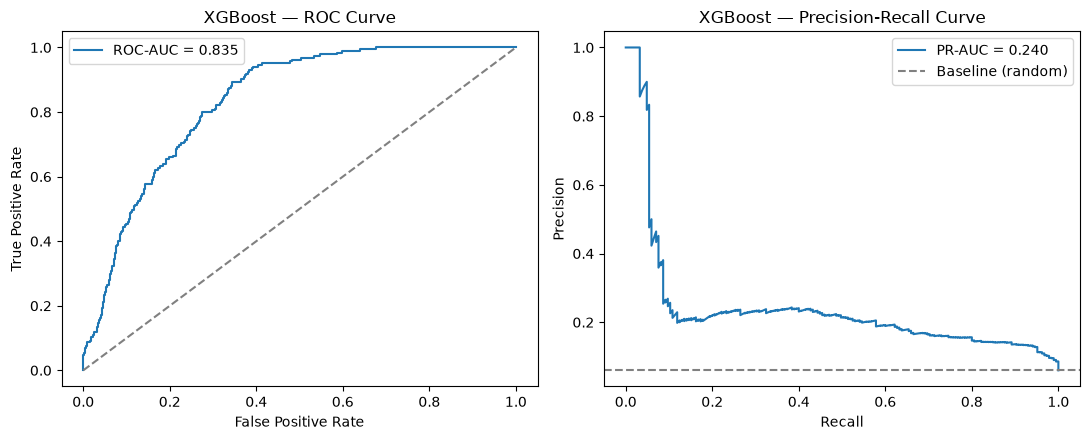

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

fpr, tpr, _ = roc_curve(y_test, xgb_test_proba)
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {xgb_metrics['ROC-AUC']:.3f}")
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('XGBoost — ROC Curve'); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, xgb_test_proba)
axes[1].plot(rec, prec, label=f"PR-AUC = {xgb_metrics['PR-AUC']:.3f}")
axes[1].axhline(y_test.mean(), color='gray', ls='--', label='Baseline (random)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('XGBoost — Precision-Recall Curve'); axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Feature importance (top 20)

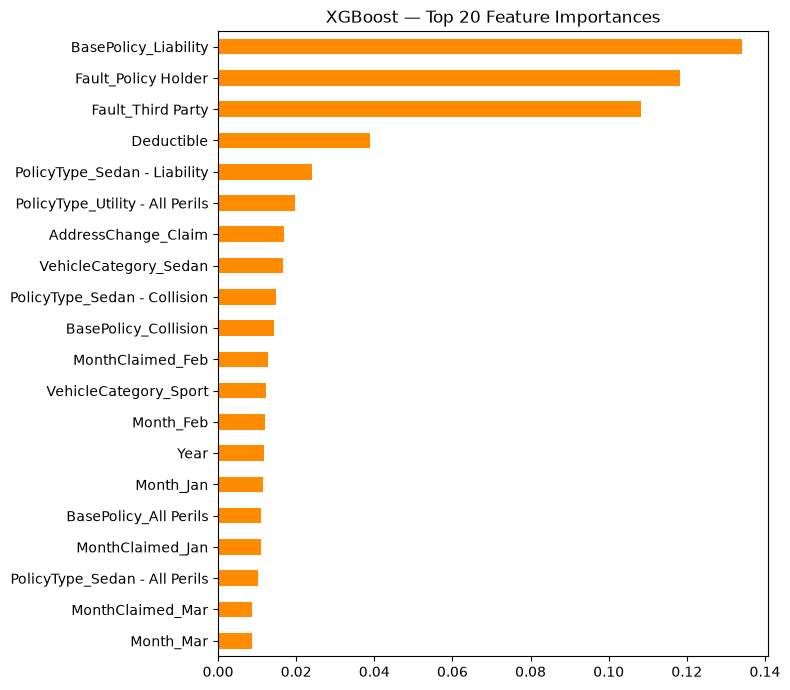

BasePolicy_Liability               0.134163
Fault_Policy Holder                0.118269
Fault_Third Party                  0.108342
Deductible                         0.038912
PolicyType_Sedan - Liability       0.023962
PolicyType_Utility - All Perils    0.019639
AddressChange_Claim                0.016906
VehicleCategory_Sedan              0.016552
PolicyType_Sedan - Collision       0.014751
BasePolicy_Collision               0.014406
MonthClaimed_Feb                   0.012904
VehicleCategory_Sport              0.012219
Month_Feb                          0.012021
Year                               0.011698
Month_Jan                          0.011551
BasePolicy_All Perils              0.011095
MonthClaimed_Jan                   0.010982
PolicyType_Sedan - All Perils      0.010119
MonthClaimed_Mar                   0.008782
Month_Mar                          0.008670
dtype: float32


In [10]:
if hasattr(best_xgb, "feature_importances_"):
    importances = pd.Series(best_xgb.feature_importances_, index=X_train_final.columns)
    top20 = importances.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8,7))
    top20.sort_values().plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title('XGBoost — Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()

    print(top20)
else:
    print("This estimator does not expose feature_importances_.")


## 8. Save the model + test-set predictions

`xgb_test_predictions.csv` is reused by the Ensemble notebook's meta-learner, alongside Random
Forest's and Isolation Forest's outputs.

In [11]:
import joblib

joblib.dump(best_xgb, "xgb_model.pkl")

xgb_results = pd.DataFrame({
    'index': X_test_final.index,
    'true_label': y_test.values,
    'xgb_proba': xgb_test_proba,
    'xgb_pred': xgb_test_pred,
})
xgb_results.to_csv("xgb_test_predictions.csv", index=False)
print("Saved xgb_model.pkl and xgb_test_predictions.csv")
xgb_results.head(10)


Saved xgb_model.pkl and xgb_test_predictions.csv


,index,true_label,xgb_proba,xgb_pred
0,8922,0,0.018200,0
1,4274,0,0.143166,0
2,3408,0,0.002718,0
3,10675,0,0.581552,1
4,3285,0,0.179855,0
5,11043,0,0.554472,1
6,3495,0,0.004086,0
7,9299,1,0.746694,1
8,10652,0,0.003407,0
9,13126,0,0.004479,0
